In [3]:
# %%
# Analyze optimization metrics
# Open this file in Jupyter / VS Code and run cell by cell.

# %%
from __future__ import annotations

import re
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# %%
def parse_run_timestamp(run_dir_name: str) -> datetime | None:
    match = re.match(r"^(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", run_dir_name)
    if match is None:
        return None

    try:
        return datetime.strptime(match.group(1), "%Y-%m-%d_%H-%M-%S")
    except ValueError:
        return None


def find_latest_run_dir(optimization_output_root: Path, index: int = 0) -> Path:
    if not optimization_output_root.exists():
        raise FileNotFoundError(f"OptimizationOutput folder does not exist: {optimization_output_root}")

    if index < 0:
        raise ValueError(f"index must be non-negative, got: {index}")

    candidate_run_dirs: list[dict[str, Any]] = []

    for child in optimization_output_root.iterdir():
        if not child.is_dir():
            continue

        metrics_csv_path = child / "metrics.csv"
        if not metrics_csv_path.exists():
            continue

        candidate_run_dirs.append(
            {
                "run_dir": child,
                "parsed_timestamp": parse_run_timestamp(child.name),
                "modified_time": metrics_csv_path.stat().st_mtime,
            }
        )

    if not candidate_run_dirs:
        raise FileNotFoundError(f"No run folders with metrics.csv found under: {optimization_output_root}")

    candidate_run_dirs.sort(
        key=lambda item: (
            item["parsed_timestamp"] is not None,
            item["parsed_timestamp"] if item["parsed_timestamp"] is not None else datetime.min,
            item["modified_time"],
        ),
        reverse=True,
    )

    if index >= len(candidate_run_dirs):
        raise IndexError(
            f"Requested index {index}, but only {len(candidate_run_dirs)} run(s) were found."
        )

    return candidate_run_dirs[index]["run_dir"]


def numeric_columns(dataframe: pd.DataFrame) -> list[str]:
    return [
        column_name
        for column_name in dataframe.columns
        if pd.api.types.is_numeric_dtype(dataframe[column_name])
    ]


def columns_containing(dataframe: pd.DataFrame, text: str) -> list[str]:
    if text.strip() == "":
        return []
    return [
        column_name
        for column_name in dataframe.columns
        if text.lower() in column_name.lower()
    ]


Run directory : /home/magnus/CLionProjects/DifferentiablePointRendering/Assets/OptimizationOutput/2026-05-21_16-04-56_lr0.0025_it100000_plane_4
Metrics CSV   : /home/magnus/CLionProjects/DifferentiablePointRendering/Assets/OptimizationOutput/2026-05-21_16-04-56_lr0.0025_it100000_plane_4/metrics.csv
Rows          : 1004
Columns       : 25


,iteration,camera_name,loss_rgb_sum,loss_depth_distortion_raw_sum,loss_depth_distortion_weighted_sum,loss_normal_consistency_raw_sum,loss_normal_consistency_weighted_sum,loss_opacity_regularizer,loss_total_sum,parameter_mse,...,grad_position_depth_distortion_rms,grad_position_depth_distortion_max,grad_position_normal_consistency_rms,grad_position_normal_consistency_max,grad_position_total_rms,grad_position_total_max,grad_opacity_total_rms,grad_opacity_total_max,grad_opacity_regularizer_rms,grad_opacity_regularizer_max
0,1,ALL_CAMERAS,0.186358,6.875254e-11,6.875254e-05,0.000000e+00,0.000000e+00,0.025000,0.211427,0.000006,...,0.004896,0.010504,0.000000e+00,0.000000e+00,0.005073,0.010880,0.010642,0.012043,0.010050,0.011111
1,2,ALL_CAMERAS,0.186261,1.049172e-11,1.049172e-05,0.000000e+00,0.000000e+00,0.024751,0.211022,0.000022,...,0.001181,0.002502,0.000000e+00,0.000000e+00,0.001309,0.002334,0.010629,0.012009,0.010000,0.011056
2,3,ALL_CAMERAS,0.186164,9.886148e-13,9.886148e-07,1.390775e-07,1.390775e-11,0.024503,0.210667,0.000048,...,0.000164,0.000335,1.346131e-12,3.830288e-12,0.000625,0.001285,0.010597,0.011983,0.009950,0.011000
3,4,ALL_CAMERAS,0.186064,7.566643e-14,7.566643e-08,8.514949e-08,8.514949e-12,0.024256,0.210319,0.000081,...,0.000016,0.000031,5.906957e-13,1.151318e-12,0.000579,0.001270,0.010565,0.011951,0.009900,0.010944
4,5,ALL_CAMERAS,0.185962,1.407812e-14,1.407812e-08,1.243183e-07,1.243183e-11,0.024010,0.209972,0.000123,...,0.000004,0.000009,4.345267e-13,7.686174e-13,0.000547,0.001226,0.010529,0.011920,0.009849,0.010889


Selected columns:
  loss_rgb_sum
  loss_total_sum
  grad_position_renderer_rms
  grad_position_depth_distortion_rms
  grad_position_normal_consistency_rms
  grad_position_total_rms
  grad_position_renderer_max
  grad_position_depth_distortion_max
  grad_position_normal_consistency_max
  grad_position_total_max
  num_points


,count,mean,std,min,25%,50%,75%,max
loss_rgb_sum,1004.0,0.049421,0.050273,0.021184,0.023219,0.024367,0.038023,0.186358
loss_total_sum,1004.0,0.051216,0.054574,0.021194,0.023258,0.024434,0.038126,0.211427
grad_position_renderer_rms,1004.0,0.004927,0.003530,0.000421,0.003967,0.004551,0.005349,0.077471
grad_position_depth_distortion_rms,1004.0,0.006422,0.005367,0.000004,0.004099,0.005306,0.007018,0.063202
grad_position_normal_consistency_rms,1004.0,0.000023,0.000027,0.000000,0.000009,0.000013,0.000025,0.000255
grad_position_total_rms,1004.0,0.006594,0.007047,0.000446,0.003172,0.004868,0.007413,0.076575
grad_position_renderer_max,1004.0,0.010746,0.011424,0.000685,0.007741,0.009272,0.011289,0.256430
grad_position_depth_distortion_max,1004.0,0.013932,0.013602,0.000009,0.008125,0.011160,0.015206,0.182257
grad_position_normal_consistency_max,1004.0,0.000051,0.000066,0.000000,0.000018,0.000028,0.000053,0.000738
grad_position_total_max,1004.0,0.014710,0.019237,0.000783,0.006103,0.009765,0.015877,0.253491


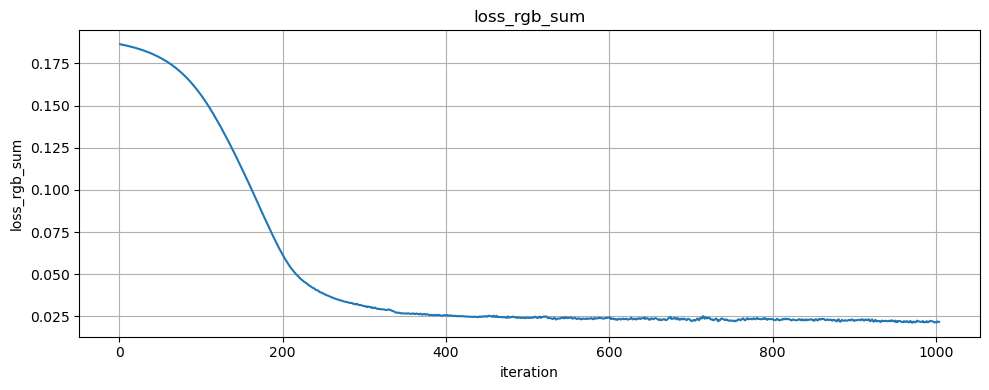

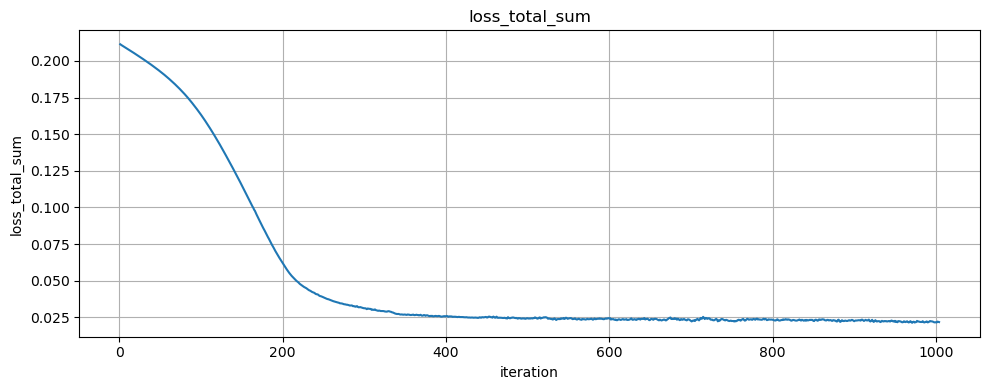

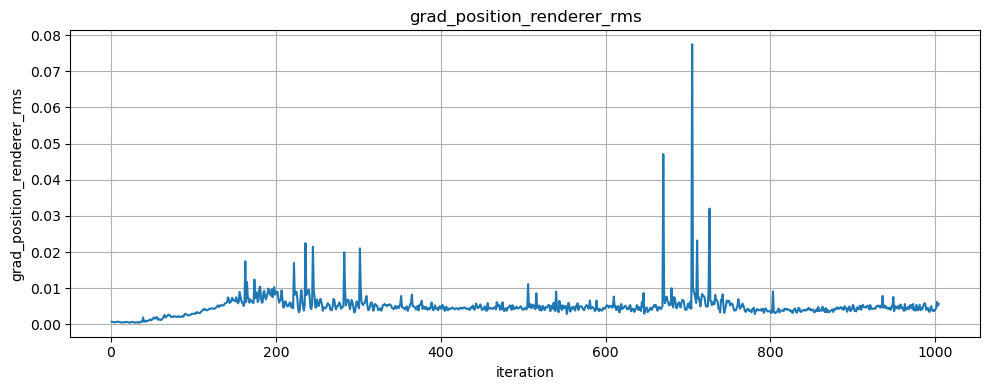

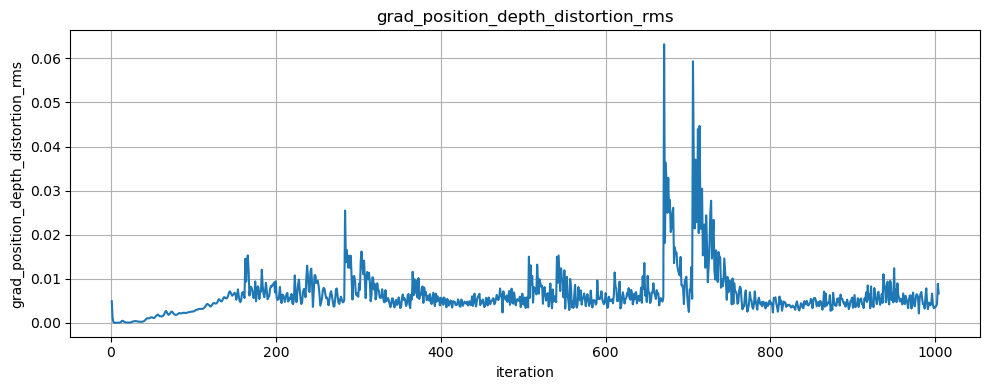

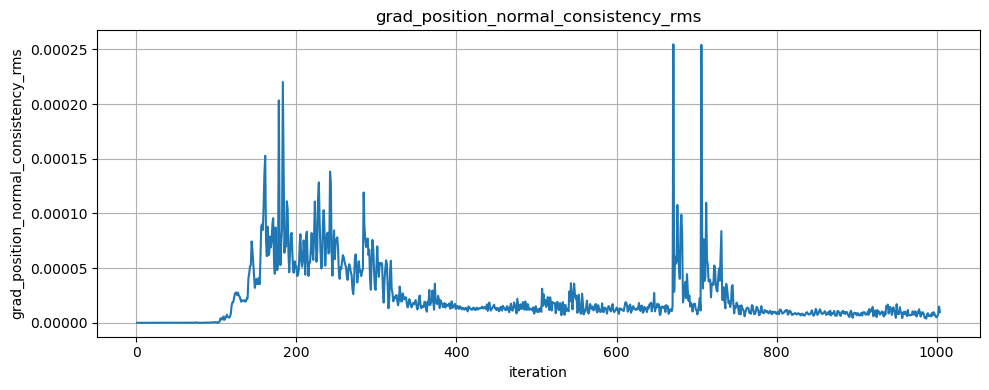

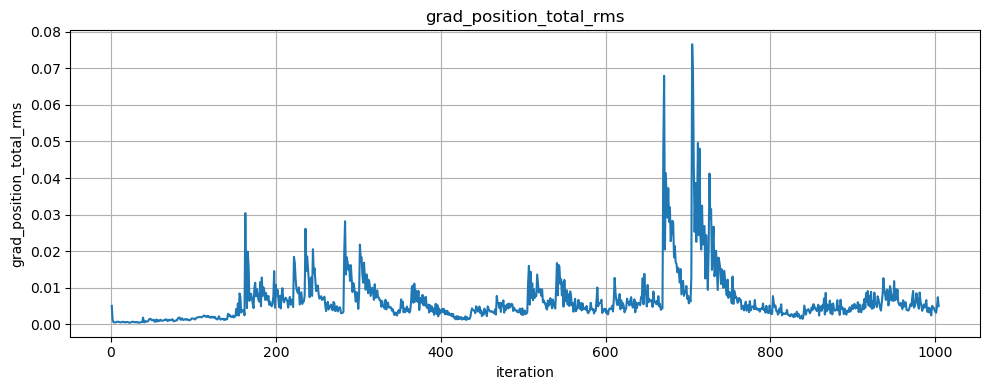

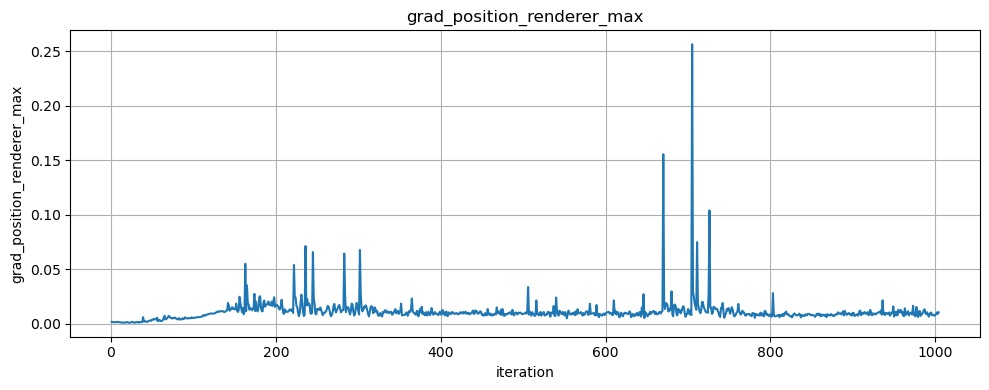

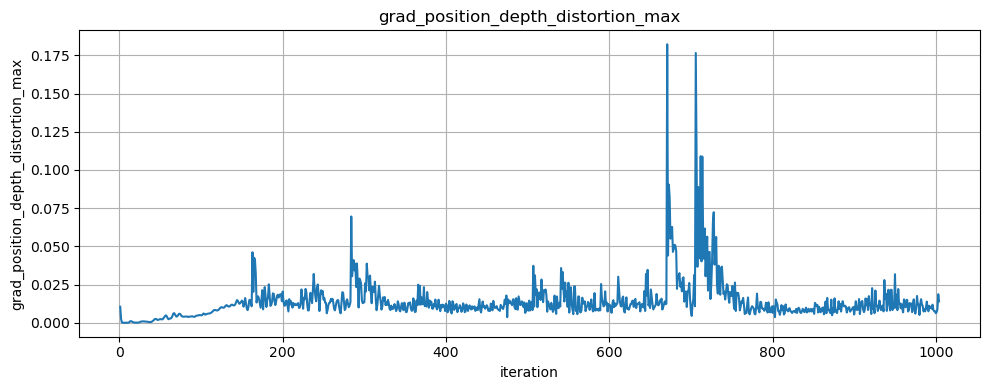

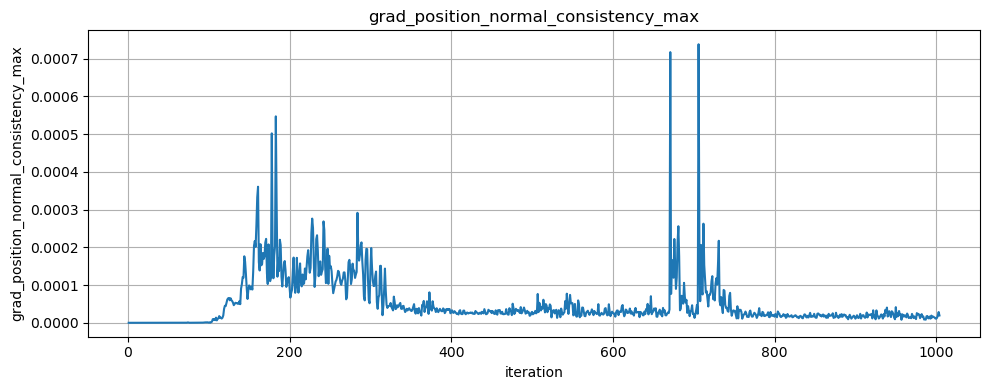

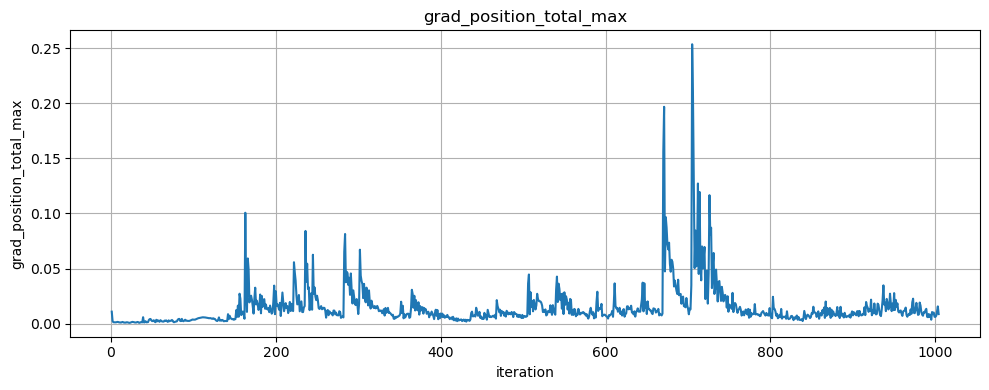

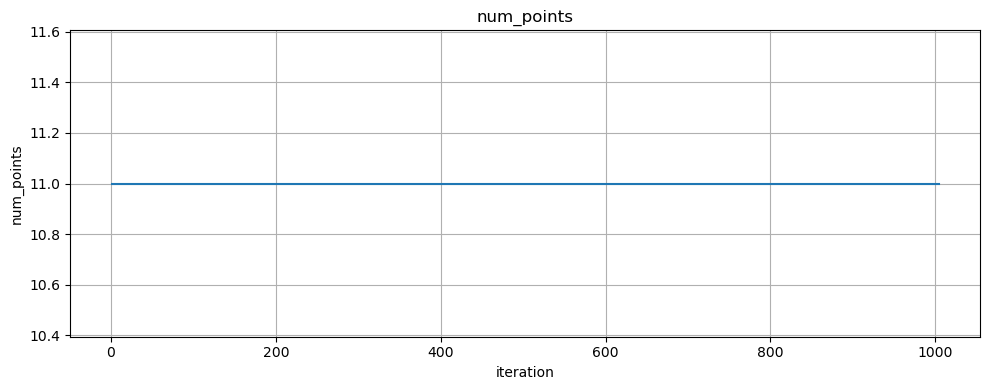

In [5]:

# %%
# -----------------------------
# User settings
# -----------------------------

optimization_output_root = Path("../../Assets/OptimizationOutput")

# Set to a concrete run directory if you do not want the latest run:
# run_dir = Path("../Assets/OptimizationOutput/2026-05-21_12-34-56_my_run")
run_dir = None

# 0 = latest, 1 = second latest, 2 = third latest, ...
run_index = 0

# Use None for all iterations, or e.g. 100 for the last 100 rows.
last_iterations = None

# Prefer aggregated rows if your CSV has camera_name == "ALL_CAMERAS".
# Set to None to keep all cameras.
camera_name_filter = "ALL_CAMERAS"

# Pick columns manually.
selected_columns = [
    "loss_rgb_sum",
    "loss_total_sum",

    "grad_position_renderer_rms",
    "grad_position_depth_distortion_rms",
    "grad_position_normal_consistency_rms",
    "grad_position_total_rms",

    "grad_position_renderer_max",
    "grad_position_depth_distortion_max",
    "grad_position_normal_consistency_max",
    "grad_position_total_max",

    "num_points",
]

# Or set this to e.g. "grad_position", "loss", "opacity", "normal".
# If non-empty, this overrides selected_columns.
column_name_contains = ""

# %%
# -----------------------------
# Load metrics.csv
# -----------------------------

resolved_run_dir = Path(run_dir).resolve() if run_dir is not None else find_latest_run_dir(
    optimization_output_root=optimization_output_root,
    index=run_index,
).resolve()

metrics_csv_path = resolved_run_dir / "metrics.csv"
if not metrics_csv_path.exists():
    raise FileNotFoundError(f"Missing metrics.csv: {metrics_csv_path}")

metrics = pd.read_csv(metrics_csv_path)

if camera_name_filter is not None and "camera_name" in metrics.columns:
    mask = metrics["camera_name"].astype(str) == str(camera_name_filter)
    if mask.any():
        metrics = metrics.loc[mask].copy()

if "iteration" in metrics.columns:
    metrics = metrics.sort_values("iteration").reset_index(drop=True)

if last_iterations is not None:
    metrics = metrics.tail(int(last_iterations)).reset_index(drop=True)

print(f"Run directory : {resolved_run_dir}")
print(f"Metrics CSV   : {metrics_csv_path}")
print(f"Rows          : {len(metrics)}")
print(f"Columns       : {len(metrics.columns)}")

display(metrics.head())

# %%
# -----------------------------
# Choose columns
# -----------------------------

if column_name_contains.strip():
    columns_to_analyze = columns_containing(metrics, column_name_contains)
else:
    columns_to_analyze = [column for column in selected_columns if column in metrics.columns]

missing_columns = [column for column in selected_columns if column not in metrics.columns]

print("Selected columns:")
for column in columns_to_analyze:
    print(f"  {column}")

if missing_columns and not column_name_contains.strip():
    print("\nMissing columns:")
    for column in missing_columns:
        print(f"  {column}")

if not columns_to_analyze:
    print("\nNo selected columns found. Available numeric columns:")
    for column in numeric_columns(metrics):
        print(f"  {column}")

# %%
# -----------------------------
# Summary statistics
# -----------------------------

summary = metrics[columns_to_analyze].apply(pd.to_numeric, errors="coerce").describe().T
display(summary)

# %%
# -----------------------------
# Plot selected columns
# -----------------------------

if not columns_to_analyze:
    raise ValueError("No columns selected. Update selected_columns or column_name_contains.")

x_values = metrics["iteration"] if "iteration" in metrics.columns else metrics.index

for column_name in columns_to_analyze:
    y_values = pd.to_numeric(metrics[column_name], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(x_values, y_values)
    plt.xlabel("iteration" if "iteration" in metrics.columns else "row")
    plt.ylabel(column_name)
    plt.title(column_name)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# %%
# -----------------------------
# Optional: plot all selected columns together
# Useful when they are on roughly the same scale.
# -----------------------------

plot_together = False

if plot_together:
    x_values = metrics["iteration"] if "iteration" in metrics.columns else metrics.index

    plt.figure(figsize=(12, 5))
    for column_name in columns_to_analyze:
        y_values = pd.to_numeric(metrics[column_name], errors="coerce")
        plt.plot(x_values, y_values, label=column_name)

    plt.xlabel("iteration" if "iteration" in metrics.columns else "row")
    plt.ylabel("value")
    plt.title("Selected metrics")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
